### EN3160 Assignment 01: Intensity Transformations and Neighborhood Filtering
#### Bandara W.D.A.C. - 230082G

In [5]:
# imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

##### Q1. Intensity tranformation on 'emma' 

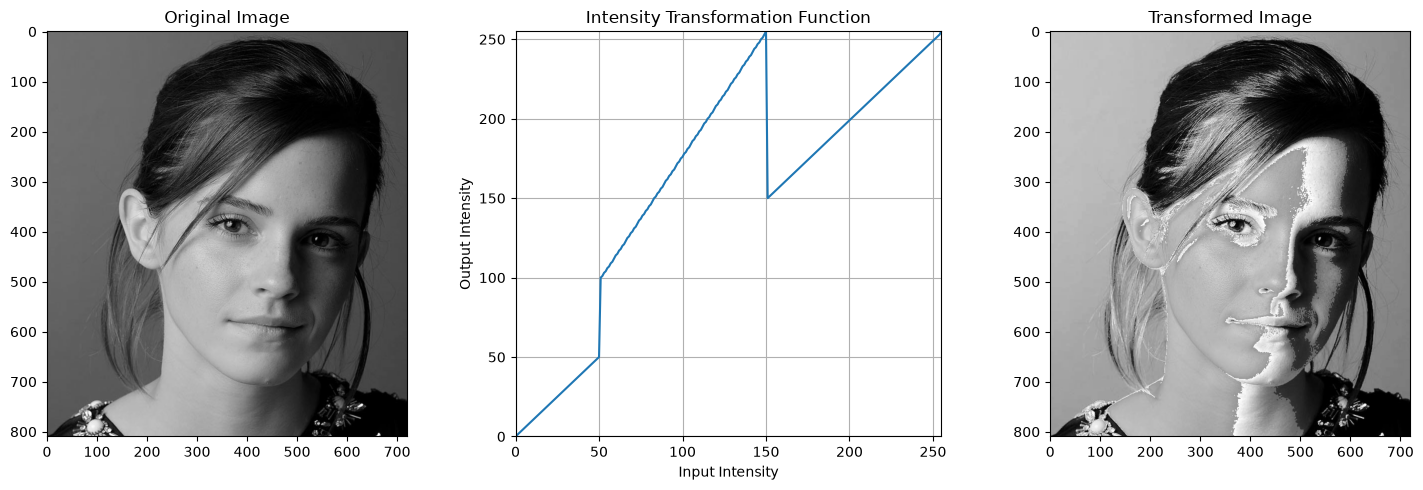

In [28]:
img_emma = cv.imread('./images/emma.jpeg', cv.IMREAD_GRAYSCALE)
assert img_emma is not None

def intensity_transform(im, breakpoints):
    tf = np.zeros(256, dtype=np.uint8)
    for i in range(len(breakpoints) - 1):
        x_start, y_start = breakpoints[i]
        x_end, y_end = breakpoints[i + 1]
        x = np.arange(x_start, x_end + 1)
        tf[x] = np.linspace(y_start, y_end, num=len(x)).astype('uint8')
    return cv.LUT(im, tf), tf

bp = np.array([(0, 0), (50, 50), (51, 100), (150, 255), (151, 150), (255, 255)])

img_transformed, tf = intensity_transform(img_emma, bp)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_emma, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(tf)
ax[1].set_title('Intensity Transformation Function')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 255])
ax[1].set_ylim([0, 255])
ax[1].grid()
ax[2].imshow(img_transformed, cmap='gray')
ax[2].set_title('Transformed Image')
plt.tight_layout()
plt.show()